You may ignore this notebook file, or use it as your final project notebook.

In [1]:
import pandas as pd
import datetime

# Impoting custom functions, classes, and scrips from project modules
from my_module.functions import calculate_decay, hours_passed, get_historical_mg
from my_module.classes import CaffeineTracker
from scripts.my_script import log_caffeine_entry

# --- Initializing Logs & Data ---
# Jupyter notebooks use UTC so -7 to convert to PST
now = datetime.datetime.now() - datetime.timedelta(hours=7)
# Load the logged data of my caffeine consumption
df = pd.read_csv('caffeine_log.csv')
# Convert the timestamp column to datetime objects to perform math operations
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Adding a column for mg of caffeine in my body at moment each row is logged
df['mg_at_log_time'] = df.apply(lambda row: get_historical_mg(row['timestamp'], df), axis=1)

# Display dataframe
df

,timestamp,drink,caffeine_mg,focus_after_one_hr,mg_at_log_time
0,2026-03-04 10:03:00,redbull,112.0,6,0.00
1,2026-03-04 17:20:00,redbull,112.0,6,40.81
2,2026-03-05 09:48:00,redbull,112.0,7,15.58
3,2026-03-06 13:30:00,celcius,200.0,9,2.75
4,2026-03-08 17:02:00,alani nu,200.0,8,0.16
5,2026-03-09 22:02:00,redbull,112.0,5,3.59
6,2026-03-10 10:35:00,alani nu,200.0,8,20.29
7,2026-03-11 09:11:00,redbull,112.0,7,9.61
8,2026-03-11 23:25:00,alani nu,200.0,8,16.90
9,2026-03-12 06:31:00,alani nu,200.0,9,81.05


In [2]:
# --- Calculating my Threshold (@ what caffeine level does my focus consistently start to fall) ---
# Identify logs where focus drops to 6 or below
start_crashing = df[df['focus_after_one_hr'] <= 6]
# Calculate the threshold as the maximum caffeine level during these 'crash' events
my_threshold = start_crashing['mg_at_log_time'].max()
print(f"My crash threshold is approximately: {my_threshold}")

# --- Tracker Intialization ---
# Apply my calculated threshold to the tracker
tracker = CaffeineTracker(crash_threshold=my_threshold) 
# See current caffeine levels by loading drink logs into the tracker
for index, row in df.iterrows():
    tracker.add_drink(
        row['drink'],
        row['caffeine_mg'],
        row['timestamp']
    )

# --- Live Caffeine Status & Prediction ---
# Formating timestamp for printing
time_string = now.strftime("%b %d, %I:%M %p")
current_mg = tracker.get_total_current_caffeine()
print(f"Current ({time_string}) caffeine in system: {current_mg} mg")
print(tracker.predict_crash())

My crash threshold is approximately: 40.81
Logged 112.0mg from redbull 7 days ago
Logged 112.0mg from redbull 7 days ago
Logged 112.0mg from redbull 6 days ago
Logged 200.0mg from celcius 5 days ago
Logged 200.0mg from alani nu 3 days ago
Logged 112.0mg from redbull 2 days ago
Logged 200.0mg from alani nu 1 day ago
Logged 112.0mg from redbull today
Logged 200.0mg from alani nu today
Logged 200.0mg from alani nu today
Current (Mar 12, 07:22 AM) caffeine in system: 249.41 mg
You have approximately 783.5 minutes of focus left.


In [3]:
# Want to add another entry to the Data Frame?
log_caffeine_entry()

Do you want to add an entry to the dataframe? (yes/no):  no


In [4]:
# If you added a new entry, load the updated file
df = pd.read_csv('caffeine_log.csv')
# Re-convert the timestamp so your math doesn't break
df['timestamp'] = pd.to_datetime(df['timestamp'])
# Verify the new entry is there
print(f"Total logs: {len(df)}")
df['mg_at_log_time'] = df.apply(lambda row: get_historical_mg(row['timestamp'], df), axis=1)
# See new dataframe with new entry!
df

Total logs: 10


,timestamp,drink,caffeine_mg,focus_after_one_hr,mg_at_log_time
0,2026-03-04 10:03:00,redbull,112.0,6,0.00
1,2026-03-04 17:20:00,redbull,112.0,6,40.81
2,2026-03-05 09:48:00,redbull,112.0,7,15.58
3,2026-03-06 13:30:00,celcius,200.0,9,2.75
4,2026-03-08 17:02:00,alani nu,200.0,8,0.16
5,2026-03-09 22:02:00,redbull,112.0,5,3.59
6,2026-03-10 10:35:00,alani nu,200.0,8,20.29
7,2026-03-11 09:11:00,redbull,112.0,7,9.61
8,2026-03-11 23:25:00,alani nu,200.0,8,16.90
9,2026-03-12 06:31:00,alani nu,200.0,9,81.05


Finally, graphing/visualizing the data.

Text(0, 0.5, 'Focus Score (1-10)')

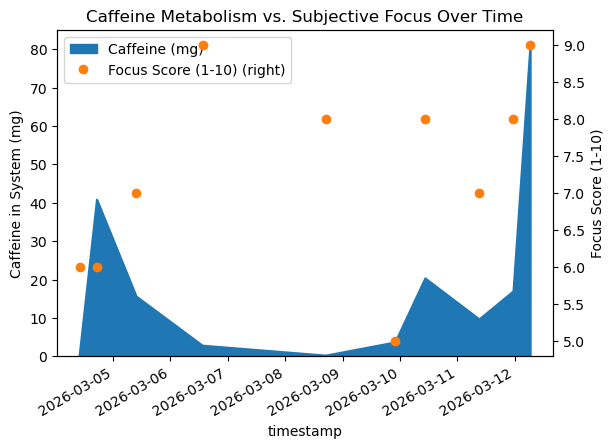

In [5]:
# --- Area Chart ---
# Set index to timestamp so we don't have to deal with x-axis
plot_df = df.set_index('timestamp').sort_index()
graph = plot_df['mg_at_log_time'].plot(
    kind='area', 
    label='Caffeine (mg)',
    legend=True,
    title='Caffeine Metabolism vs. Subjective Focus Over Time'
)

# Overlay my focus scores
plot_df['focus_after_one_hr'].plot(
    secondary_y=True, 
    ax=graph,
    style='o',
    label='Focus Score (1-10)',
    legend=True
)

graph.set_ylabel('Caffeine in System (mg)')
graph.right_ax.set_ylabel('Focus Score (1-10)')

Testing the functions!

In [12]:
!export PYTHONPATH=$PYTHONPATH:. ; pytest

============================= test session starts ==============================
platform linux -- Python 3.11.9, pytest-8.3.4, pluggy-1.5.0
rootdir: /home/nan028/Final_Project
plugins: anyio-4.3.0
collected 2 items                                                              

my_module/test_folder/test_functions.py ..                               [100%]

============================== 2 passed in 0.01s ===============================
